# Datenanalyse mit SQL & Python - Tag 4: Übungen

**Teil A:** Warm-up mit Shop-Daten als Recap zu Tag 3  
**Teil B:** Cleaning, EDA & Reporting mit messy HR Data  
**Mini-Projekt:** Welche Faktoren hängen mit Gehaltsstruktur oder Fluktuationsrisiko im HR-Datensatz zusammen?



## Lernziele

In diesen Übungen trainierst du:

- Inhalte vom Vortag mit Shop-Daten zu wiederholen: Pandas-Überblick, Data Quality Check, `merge`, Feature Engineering, `groupby`, Pivot und Visualisierung
- eine kleine Business-Frage aus Shop-Daten datenbasiert zu beantworten
- einen messy HR-Datensatz zu prüfen und zu bereinigen
- HR-Kennzahlen mit Pandas und SQL zu analysieren
- Verteilungen, Gruppenunterschiede und Korrelationen zu visualisieren
- aus HR-Daten eine datenbasierte Handlungsempfehlung abzuleiten



# 09:00–09:30 | Tag-3-Refresh


## Einrichtung & Daten laden

Führe diese Zelle zuerst aus. Sie lädt:

- `shop_joined` für den Warm-up
- `hr_raw` aus dem Messy-dataset Repository
- `hr` als Arbeitskopie für Cleaning und EDA



In [43]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 100)

SHOP_DIR = 'https://raw.githubusercontent.com/chiaoya/Data_to_Decision_with_SQL_Python/refs/heads/main/course_data/shop/'
orders = pd.read_csv(SHOP_DIR + 'shop_orders.csv')
customers = pd.read_csv(SHOP_DIR + 'shop_customers.csv')
products = pd.read_csv(SHOP_DIR +  'shop_products.csv')

shop_joined = orders.merge(customers, on='customer_id', how='left').merge(products, on='product_id', how='left')
shop_joined['revenue'] = shop_joined['quantity'] * shop_joined['price']

HR_DATA_URL = 'https://raw.githubusercontent.com/eyowhite/Messy-dataset/main/messy_HR_data.csv'
hr_raw = pd.read_csv(HR_DATA_URL, engine='python', on_bad_lines='warn')
hr = hr_raw.copy()

print('shop_joined:', shop_joined.shape)
print('hr_raw:', hr_raw.shape)
hr_raw.head()



shop_joined: (50, 11)
hr_raw: (1000, 10)


,Name,Age,Salary,Gender,Department,Position,Joining Date,Performance Score,Email,Phone Number
0,grace,25,50000,Male,HR,Manager,"April 5, 2018",D,email@example.com,NaN
1,david,NaN,65000,Female,Finance,Director,2020/02/20,F,user@domain.com,123-456-7890
2,hannah,35,SIXTY THOUSAND,Female,Sales,Director,01/15/2020,C,email@example.com,098-765-4321
3,eve,NaN,50000,Female,IT,Manager,"April 5, 2018",A,name@company.org,
4,grace,NaN,NAN,Female,Finance,Manager,01/15/2020,F,name@company.org,098-765-4321


## Teil A: 30-Minuten-Refresh mit Shop-Daten als Recap zu Tag 3

Arbeite mit `shop_joined`. Ziel ist, die wichtigsten Inhalte vom Vortag aktiv zu wiederholen: DataFrame-Überblick, Data Quality, `merge`, neue Kennzahlen, `groupby`, Pivot und Visualisierung.

**Business-Frage für den Refresh:** Welche Städte und Produktkategorien tragen am stärksten zum Umsatz bei?

**Timing-Vorschlag:**

- A1-A2: 8 Minuten Daten verstehen und Qualität prüfen
- A3-A4: 10 Minuten Kennzahlen und Aggregationen
- A5-A6: 10 Minuten Pivot, Visualisierung und kurze Interpretation
- 2 Minuten Austausch im Plenum



### Übung A1: DataFrame-Überblick (ca. 4 Minuten)

**Aufgabe:** Zeige die ersten Zeilen, die Form, die Spaltennamen und die Datentypen von `shop_joined`.



In [ ]:
shop_joined._____()



In [ ]:
shop_joined._____



In [ ]:
shop_joined._____.tolist()



In [ ]:
shop_joined._____()



### Übung A2: Data Quality & Merge-Check (ca. 4 Minuten)

**Aufgabe:** Prüfe, ob nach dem Zusammenführen fehlende Kunden- oder Produktinformationen entstanden sind.

Hinweis: Wenn `name`, `city`, `product_name`, `category` oder `price` fehlen, hat der Join nicht für alle Zeilen passende Informationen gefunden.



In [ ]:
quality_check = shop_joined[['name', 'city', 'product_name', 'category', 'price']]._____().sum()
quality_check



In [ ]:
print('Zeilen:', len(shop_joined))
print('Bestellungen:', shop_joined['order_id']._____())
print('Kunden:', shop_joined['customer_id']._____())
print('Produkte:', shop_joined['product_id']._____())



### Übung A3: Kennzahlen vorbereiten (ca. 5 Minuten)

**Aufgabe:** Erstelle eine Arbeitskopie `shop_analysis` und ergänze zwei neue Spalten:

- `revenue_per_item`: Umsatz pro Stück
- `age_group`: Altersgruppe der Kundinnen und Kunden



In [ ]:
shop_analysis = shop_joined.copy()

shop_analysis['revenue_per_item'] = shop_analysis['_____'] / shop_analysis['_____']
shop_analysis['age_group'] = pd.cut(
    shop_analysis['age'],
    bins=[0, 30, 45, 60, 120],
    labels=['bis 30', '31-45', '46-60', '60+']
)

shop_analysis[['age', 'age_group', 'quantity', 'price', 'revenue', 'revenue_per_item']].head()



### Übung A4: `groupby` mit mehreren Kennzahlen (ca. 6 Minuten)

**Aufgabe:** Berechne pro Stadt:

- Gesamtumsatz
- Anzahl Bestellungen
- durchschnittlichen Bestellwert
- durchschnittliche Menge pro Bestellung

Sortiere die Tabelle nach Umsatz absteigend.



In [ ]:
city_report = (
    shop_analysis
    .groupby('_____', as_index=False)
    .agg(
        total_revenue=('_____', 'sum'),
        orders=('_____', 'nunique'),
        avg_order_value=('_____', 'mean'),
        avg_quantity=('_____', 'mean')
    )
    .sort_values('_____', ascending=False)
)
city_report



### Übung A5: Pivot-Tabelle Stadt x Kategorie (ca. 5 Minuten)

**Aufgabe:** Erstelle eine Pivot-Tabelle, die den Umsatz je Stadt und Produktkategorie zeigt.



In [ ]:
city_category_pivot = pd.pivot_table(
    shop_analysis,
    index='_____',
    columns='_____',
    values='_____',
    aggfunc='_____',
    fill_value=0
)

city_category_pivot



### Übung A6: Visualisierung & Mini-Interpretation (ca. 8 Minuten)

**Aufgabe:** Visualisiere den Umsatz pro Produktkategorie und formuliere danach eine kurze Business-Aussage.



In [ ]:
category_report = (
    shop_analysis
    .groupby('category', as_index=False)
    .agg(total_revenue=('revenue', 'sum'))
    .sort_values('total_revenue', ascending=False)
)

sns.barplot(data=category_report, x='total_revenue', y='category')
plt.title('Tag-3-Refresh: Umsatz pro Produktkategorie')
plt.xlabel('Umsatz')
plt.ylabel('Kategorie')
plt.show()



In [ ]:
top_category = category_report.iloc[0]
print(f"Business Takeaway: Die Kategorie {top_category['category']} erzielt mit {top_category['total_revenue']:.0f} den höchsten Umsatz.")



# 14:20–15:40 | Praxis mit Day_3_Exercise_Teil B


## Teil B: Cleaning, EDA & Reporting mit messy HR Data

Arbeite mit `hr_raw` und `hr`. Der Datensatz stammt aus dem Repository `eyowhite/Messy-dataset`.

**Business-Kontext:** Die HR-Abteilung möchte verstehen, welche Faktoren mit Gehaltsstruktur, Zufriedenheit oder möglichem Fluktuationsrisiko zusammenhängen.



### Übung B1: Schnell-Check

**Aufgabe:** Prüfe Form, Spalten, Datentypen, fehlende Werte und Duplikate.



In [44]:
print('Form:', hr_raw.shape)
print()
print('Spalten:')
print(hr_raw.columns.tolist())
print()
print('Datentypen:')
print(hr_raw.dtypes)
print()
print('Fehlende Werte:')
print(hr_raw.isna().sum().sort_values(ascending=False).head(20))
print()
print('Duplikate:', hr_raw.duplicated().sum())



Form: (1000, 10)

Spalten:
['Name', 'Age', 'Salary', 'Gender', 'Department', 'Position', 'Joining Date', 'Performance Score', 'Email', 'Phone Number']

Datentypen:
Name                 str
Age                  str
Salary               str
Gender               str
Department           str
Position             str
Joining Date         str
Performance Score    str
Email                str
Phone Number         str
dtype: object

Fehlende Werte:
Email                390
Phone Number         185
Age                  159
Name                   0
Salary                 0
Gender                 0
Department             0
Position               0
Joining Date           0
Performance Score      0
dtype: int64

Duplikate: 0


### Übung B2: Datenqualität beobachten und Cleaning-Prioritäten setzen

**Aufgabe:** Schau dir die ersten Zeilen bewusst wie ein:e Analyst:in an. Welche Werte sehen technisch vorhanden aus, sind aber fachlich problematisch?

**Die 3 wichtigsten Cleaning-Entscheidungen in diesem HR-Datensatz:**

1. **`Age = 0` ist fachlich unmöglich.**  
   Solche Werte dürfen nicht als echtes Alter in Mittelwerte oder Gruppenvergleiche eingehen.

2. **`Joining Date` enthält fehlende Werte und muss ein echtes Datum werden.**  
   Für Beschäftigungsdauer oder Seniorität brauchen wir ein Datumsformat und eine Flag-Spalte für fehlende Werte.

3. **`Email` und `Phone Number` enthalten Platzhalter.**  
   Werte wie `no_email@example.com`, `email@example.com` oder `000-000-0000` sind keine echten Kontaktinformationen.

**Weitere sinnvolle Cleaning-Punkte:**

- `Salary` als Zahl prüfen und fehlende Werte transparent ergänzen.
- `Performance Score` als geordnete Skala abbilden, z. B. `A=5`, `B=4`, `C=3`, `D=2`, `F=1`.
- Textspalten wie `Gender`, `Department` und `Position` vereinheitlichen.
- Duplikate prüfen, aber nicht blind löschen.



In [ ]:
# Vorschau: Welche Probleme erkennt ihr direkt in den ersten Zeilen?
hr_raw.head(10)



### Übung B3: Basis-Cleaning für Spaltennamen und Textwerte

**Aufgabe:** Erstelle eine Arbeitskopie `hr`, vereinheitliche Spaltennamen, entferne Leerzeichen aus Textspalten und wandle leere Strings in `NA` um.



In [ ]:
# Wir arbeiten auf einer Kopie, damit hr_raw als Rohdaten-Version erhalten bleibt.
hr = hr_raw.copy()

# Spaltennamen vereinheitlichen:
# - Leerzeichen entfernen
# - alles klein schreiben
# - Leerzeichen und Bindestriche durch Unterstriche ersetzen
# Dadurch können wir später stabil mit hr['salary'] oder hr['joining_date'] arbeiten.
hr.columns = (
    hr.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)

# Alle Textspalten als pandas String speichern und führende/folgende Leerzeichen entfernen.
# Das verhindert z. B. getrennte Gruppen wie 'HR' und ' HR '.
text_cols = hr.select_dtypes(include=['object']).columns
for col in text_cols:
    hr[col] = hr[col].astype('string').str.strip()

# Leere Strings sind fachlich fehlende Werte und werden als pd.NA markiert.
hr = hr.replace(r'^\s*$', pd.NA, regex=True)

hr.head()



### Übung B4: Die 3 wichtigsten Cleaning-Entscheidungen umsetzen

Jetzt bearbeiten wir die wichtigsten fachlichen Risiken: ungültiges Alter, Datumswerte und Kontakt-Platzhalter.



In [ ]:
# ------------------------------------------------------------
# 1) Age: 0 oder fehlend ist kein plausibles Alter.
# ------------------------------------------------------------

# Age sicherheitshalber in eine numerische Spalte umwandeln.
# Nicht lesbare Werte werden zu NaN.
hr['age'] = pd.to_numeric(hr['age'], errors='coerce')

# Flag-Spalte: Welche Zeilen hatten ein fehlendes oder ungültiges Alter?
# Für HR-Daten ist age <= 0 nicht plausibel.
hr['age_was_invalid'] = hr['age'].le(0) | hr['age'].isna()

# Analyse-Spalte erstellen: ungültige Alterswerte zuerst auf NaN setzen.
hr['age_clean'] = hr['age'].mask(hr['age_was_invalid'])

# Lösungsvorschlag: fehlende Alterswerte mit dem Median der jeweiligen Abteilung füllen.
# Warum? Altersstrukturen können je Department unterschiedlich sein.
age_median_by_department = hr['age_clean'].groupby(hr['department']).transform('median')
hr['age_clean'] = hr['age_clean'].fillna(age_median_by_department)

# Fallback: Falls eine Abteilung keinen Median hat, nutzen wir den globalen Median.
hr['age_clean'] = hr['age_clean'].fillna(hr['age_clean'].median())

# ------------------------------------------------------------
# 2) Joining Date: Datumsformat und Beschäftigungsdauer.
# ------------------------------------------------------------

# Joining Date in ein echtes Datumsformat umwandeln.
# Fehlerhafte oder fehlende Werte werden zu NaT, also missing datetime.
hr['joining_date_clean'] = pd.to_datetime(hr['joining_date'], errors='coerce')

# Flag-Spalte: So bleibt transparent, welche Datumswerte fehlten.
hr['joining_date_missing'] = hr['joining_date_clean'].isna()

# Reproduzierbares Referenzdatum für die Übung.
reference_date = pd.Timestamp('2026-01-01')

# Beschäftigungsdauer in Jahren berechnen.
hr['tenure_years'] = (
    (reference_date - hr['joining_date_clean']).dt.days / 365.25
).round(1)

# Negative Beschäftigungsdauer wäre unplausibel, z. B. durch zukünftige Eintrittsdaten.
hr.loc[hr['tenure_years'] < 0, 'tenure_years'] = np.nan

# ------------------------------------------------------------
# 3) Email und Phone Number: Platzhalter als fehlend markieren.
# ------------------------------------------------------------

# Emails vereinheitlichen: Kleinbuchstaben und Leerzeichen entfernen.
hr['email_clean'] = hr['email'].astype('string').str.strip().str.lower()

# Diese Werte sind fachlich Platzhalter, auch wenn sie technisch wie E-Mails aussehen.
placeholder_emails = ['no_email@example.com', 'email@example.com']
email_is_placeholder = hr['email_clean'].isin(placeholder_emails)

# Zusätzlich prüfen wir, ob ein @ enthalten ist.
email_is_invalid = ~hr['email_clean'].str.contains('@', na=False)

# Platzhalter und ungültige E-Mails werden als fehlend markiert.
hr.loc[email_is_placeholder | email_is_invalid, 'email_clean'] = pd.NA

# Telefonnummern bleiben Text, weil führende Nullen sonst verloren gehen könnten.
hr['phone_number_clean'] = hr['phone_number'].astype('string').str.strip()

# 000-000-0000 ist ein klarer Platzhalter.
phone_is_placeholder = hr['phone_number_clean'].eq('000-000-0000')
phone_is_missing = hr['phone_number_clean'].isna()
hr.loc[phone_is_placeholder | phone_is_missing, 'phone_number_clean'] = pd.NA

hr[[
    'name',
    'age', 'age_clean', 'age_was_invalid',
    'joining_date', 'joining_date_clean', 'tenure_years',
    'email', 'email_clean',
    'phone_number', 'phone_number_clean'
]].head(10)



### Übung B5: Weitere Cleaning-Schritte für Analyse und Reporting

Jetzt ergänzen wir Analyse-Spalten, die später für EDA, SQL und Reporting nützlich sind.



In [ ]:
# Salary als Zahl speichern und für Reports auf ganze Beträge runden.
# errors='coerce' wandelt nicht lesbare Werte, z. B. Text, in NaN um.
hr['salary'] = pd.to_numeric(hr['salary'], errors='coerce')
hr['salary_clean'] = hr['salary'].round(0)

# Fehlende salary-Werte werden mit dem Median-Gehalt des jeweiligen Department gefüllt.
# Wir erstellen eine neue Spalte und überschreiben nicht die Roh-Analyse-Spalte.
salary_missing_before = hr['salary_clean'].isna().sum()
salary_by_department = hr.groupby('department')['salary_clean'].transform('median')
global_salary_median = hr['salary_clean'].median()

hr['salary_filled'] = hr['salary_clean'].fillna(salary_by_department)
hr['salary_filled'] = hr['salary_filled'].fillna(global_salary_median)
hr['salary_was_imputed'] = hr['salary_clean'].isna()

# Performance Score ist ordinal: A ist besser als B, B besser als C usw.
# Mit einer Zahlenskala können wir Gruppen vergleichen oder Korrelationen berechnen.
performance_map = {'A': 5, 'B': 4, 'C': 3, 'D': 2, 'F': 1}
hr['performance_score_clean'] = (
    hr['performance_score']
    .astype('string')
    .str.strip()
    .str.upper()
    .map(performance_map)
)

# Kategoriale Spalten vereinheitlichen, damit Gruppierungen stabiler werden.
for col in ['gender', 'department', 'position']:
    hr[col] = hr[col].astype('string').str.strip().str.title()

# Duplikate prüfen: Wir löschen sie nicht automatisch.
# Ein gleicher Name kann in echten HR-Daten vorkommen; erst prüfen, dann entscheiden.
duplicate_rows = hr.duplicated().sum()

print('Fehlende salary_clean-Werte vorher:', salary_missing_before)
print('Fehlende salary_filled-Werte nachher:', hr['salary_filled'].isna().sum())
print('Duplikate nach Cleaning:', duplicate_rows)

hr.loc[
    hr['salary_was_imputed'],
    ['name', 'department', 'salary_clean', 'salary_filled', 'salary_was_imputed']
].head(10)



### Übung B6: Cleaning-Ergebnis prüfen und dokumentieren

**Aufgabe:** Erstelle eine kleine Übersicht: Welche Probleme wurden gefunden und wie wurden sie behandelt?



In [ ]:
cleaning_summary = pd.DataFrame({
    'Cleaning-Thema': [
        'Age: ungueltig oder fehlend',
        'Joining Date: fehlend oder nicht parsebar',
        'Email: Platzhalter oder ungueltig',
        'Phone Number: Platzhalter oder fehlend',
        'Salary: fehlend nach Numeric-Konvertierung',
        'Duplikate: komplette Zeilen'
    ],
    'Betroffene Zeilen': [
        int(hr['age_was_invalid'].sum()),
        int(hr['joining_date_missing'].sum()),
        int((email_is_placeholder | email_is_invalid).sum()),
        int((phone_is_placeholder | phone_is_missing).sum()),
        int(hr['salary_was_imputed'].sum()),
        int(duplicate_rows)
    ],
    'Entscheidung': [
        'age_clean mit Department-Median + globalem Fallback',
        'NaT markieren; tenure_years nur berechnen, wenn Datum vorhanden ist',
        'Als fehlend markieren, nicht fuer Analyse verwenden',
        'Als fehlend markieren, nicht fuer Analyse verwenden',
        'salary_filled mit Department-Median + globalem Fallback',
        'Nur pruefen; nicht automatisch loeschen'
    ]
})

cleaning_summary



In [ ]:
# Kontrollansicht: Rohwerte und bereinigte Analysewerte nebeneinander.
hr[[
    'name', 'department', 'position',
    'age', 'age_clean', 'age_was_invalid',
    'salary', 'salary_filled', 'salary_was_imputed',
    'joining_date', 'joining_date_clean', 'tenure_years',
    'performance_score', 'performance_score_clean',
    'email', 'email_clean',
    'phone_number', 'phone_number_clean'
]].head(10)



### B7: Explorative HR-Analyse

Wähle passende Spalten aus dem Datensatz. Je nach tatsächlicher Spaltenstruktur kannst du die folgenden Beispiele anpassen.



### Übung B7: Numerische Kennzahlen

**Aufgabe:** Berechne Kennzahlen für alle numerischen Spalten.



In [49]:
numeric_hr = hr.select_dtypes(include='number')

if numeric_hr.empty:
    print('Keine numerischen Spalten gefunden. Bitte führe zuerst Übung B3 aus und prüfe hr.dtypes.')
else:
    display(numeric_hr.describe().T)



,count,mean,std,min,25%,50%,75%,max
age,665.0,37.338346,9.012949,25.0,25.0,35.0,40.0,50.0
salary,690.0,60260.869565,7831.039009,50000.0,55000.0,65000.0,68750.0,70000.0


### Übung B8: Verteilung einer wichtigen HR-Kennzahl

**Aufgabe:** Wähle eine numerische Spalte, zum Beispiel Gehalt, Alter, Zufriedenheit oder Performance, und visualisiere die Verteilung.



In [50]:
# Wähle eine numerische Spalte aus der Ausgabe von numeric_hr.columns.
# Für die HR-Frage ist salary_filled meistens eine gute Wahl.
numeric_hr.columns



Index(['age', 'salary'], dtype='str')

In [ ]:
selected_numeric_col = 'salary_filled' if 'salary_filled' in numeric_hr.columns else numeric_hr.columns[0]

plt.hist(hr[selected_numeric_col].dropna(), bins=20)
plt.title(f'Verteilung: {selected_numeric_col}')
plt.xlabel(selected_numeric_col)
plt.ylabel('Anzahl')
plt.show()




### Übung B9: Gruppenvergleich

**Aufgabe:** Wähle eine sinnvolle kategoriale Spalte und vergleiche den Durchschnitt einer numerischen HR-Kennzahl pro Gruppe.

**Wichtig:** Nicht jede Textspalte ist eine gute Gruppierungsvariable. `name`, `email` oder `phone_number` identifizieren einzelne Personen und sind für Gruppenvergleiche ungeeignet. Sinnvoller sind zum Beispiel `department`, `gender` oder `position`.



In [52]:
# Sinnvolle Gruppen-Spalten suchen: Textspalten, aber keine ID-/Kontaktspalten.
exclude_group_cols = ['name', 'email', 'phone_number']

categorical_cols = [
    col for col in hr.select_dtypes(include=['object', 'string']).columns
    if col not in exclude_group_cols
]

group_candidates = pd.DataFrame({
    'column': categorical_cols,
    'unique_values': [hr[col].nunique(dropna=True) for col in categorical_cols],
    'examples': [hr[col].dropna().astype('string').drop_duplicates().head(5).tolist() for col in categorical_cols]
}).sort_values('unique_values')

group_candidates



,column,unique_values,examples
0,gender,3,"[Male, Female, Other]"
1,department,5,"[HR, Finance, Sales, IT, Marketing]"
2,position,5,"[Manager, Director, Clerk, Assistant, Analyst]"
3,joining_date,5,"[April 5, 2018, 2020/02/20, 01/15/2020, 03-25-..."
4,performance_score,5,"[D, F, C, A, B]"


In [58]:
# Wähle eine passende Gruppen-Spalte und Kennzahl.
selected_group_col = 'department' if 'department' in categorical_cols else categorical_cols[0]
selected_value_col = 'salary_filled' if 'salary_filled' in numeric_hr.columns else numeric_hr.columns[0]

print('Gruppierung nach:', selected_group_col)
print('Kennzahl:', selected_value_col)

group_report = (
    hr
    .groupby(selected_group_col, dropna=False)[selected_value_col]
    .agg(['count', 'mean', 'median'])
    .query('count >= 2')
    .sort_values('mean', ascending=False)
)
group_report.head(10)



Gruppierung nach: position
Kennzahl: salary


,count,mean,median
position,,,
Director,129,61162.790698,65000.0
Manager,130,60346.153846,65000.0
Analyst,146,60171.232877,65000.0
Clerk,142,60035.211268,55000.0
Assistant,143,59685.314685,55000.0


### Übung B10: Korrelationen

**Aufgabe:** Erstelle eine Korrelationsmatrix für numerische HR-Spalten.



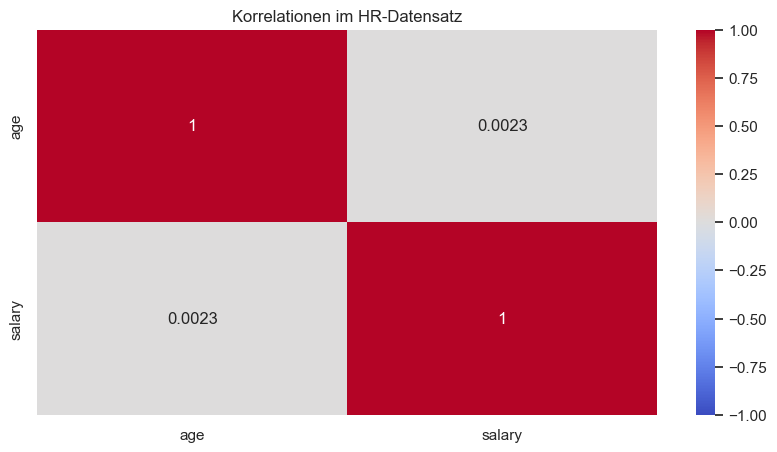

In [59]:
corr = numeric_hr.corr()

sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap='coolwarm')
plt.title('Korrelationen im HR-Datensatz')
plt.show()



### B11: SQL + Python für HR-Reporting

Speichere den bereinigten HR-DataFrame in SQLite und erstelle eine aggregierte Tabelle.



In [60]:
conn = sqlite3.connect(':memory:')
hr.to_sql('hr', conn, index=False, if_exists='replace')

# Passe group/value bei Bedarf an deine Spalten an.
group_col = selected_group_col
value_col = selected_value_col

query = f'''
SELECT
    "{group_col}" AS gruppe,
    COUNT(*) AS anzahl,
    AVG("{value_col}") AS durchschnitt
FROM hr
WHERE "{value_col}" IS NOT NULL
GROUP BY "{group_col}"
HAVING COUNT(*) >= 2
ORDER BY durchschnitt DESC;
'''

sql_hr_report = pd.read_sql_query(query, conn)
sql_hr_report.head(10)



,gruppe,anzahl,durchschnitt
0,Director,129,61162.790698
1,Manager,130,60346.153846
2,Analyst,146,60171.232877
3,Clerk,142,60035.211268
4,Assistant,143,59685.314685


### B12: Mini-Projekt HR Business Question

**Business Question:**

> Welche Faktoren hängen im HR-Datensatz mit Gehaltsstruktur, Zufriedenheit oder möglichem Fluktuationsrisiko zusammen?

Wähle eine konkrete Variante:

- Welche Abteilung oder Rolle hat auffällig hohe/niedrige Gehälter?
- Gibt es Gruppen mit niedriger Zufriedenheit oder Performance?
- Welche Merkmale könnten auf Fluktuationsrisiko hinweisen?
- Welche HR-Maßnahme würdest du empfehlen?

**Ergebnis:** 2 Diagramme, 3 Erkenntnisse, 1 Empfehlung und 1 Hinweis zur Datenqualität.



In [61]:
hr_insights = [
    'Erkenntnis 1: ...',
    'Erkenntnis 2: ...',
    'Erkenntnis 3: ...',
]
recommendation = 'Empfehlung: ...'
quality_note = 'Datenqualitäts-Hinweis: ...'

for insight in hr_insights:
    print('-', insight)
print(recommendation)
print(quality_note)



- Erkenntnis 1: ...
- Erkenntnis 2: ...
- Erkenntnis 3: ...
Empfehlung: ...
Datenqualitäts-Hinweis: ...


## Abschlussreflexion

Diskutiert kurz:

1. Welche Cleaning-Entscheidung war für die Analyse am wichtigsten?
1. Welche HR-Frage ließ sich gut beantworten?
1. Welche Aussage wäre wegen Datenqualität noch unsicher?
1. Welche zusätzliche HR-Spalte wäre für eine bessere Analyse hilfreich?



## Musterlösungen

Diese Lösungsmuster zeigen einen robusten Weg durch Cleaning, EDA und Reporting. Bei echten messy Daten sind alternative Spaltenauswahlen und Interpretationen möglich.



### Lösungen Teil A: 30-Minuten-Shop-Refresh


In [62]:
# A1: Überblick
shop_joined.head()
shop_joined.shape
shop_joined.columns.tolist()
shop_joined.info()



<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   order_id      50 non-null     int64
 1   customer_id   50 non-null     int64
 2   product_id    50 non-null     int64
 3   quantity      50 non-null     int64
 4   name          50 non-null     str  
 5   city          50 non-null     str  
 6   age           50 non-null     int64
 7   product_name  50 non-null     str  
 8   category      50 non-null     str  
 9   price         50 non-null     int64
 10  revenue       50 non-null     int64
dtypes: int64(7), str(4)
memory usage: 4.4 KB


In [63]:
# A2: Data Quality & Merge-Check
quality_check = shop_joined[['name', 'city', 'product_name', 'category', 'price']].isna().sum()
display(quality_check)

print('Zeilen:', len(shop_joined))
print('Bestellungen:', shop_joined['order_id'].nunique())
print('Kunden:', shop_joined['customer_id'].nunique())
print('Produkte:', shop_joined['product_id'].nunique())



name            0
city            0
product_name    0
category        0
price           0
dtype: int64

Zeilen: 50
Bestellungen: 50
Kunden: 19
Produkte: 17


In [64]:
# A3: Kennzahlen vorbereiten
shop_analysis = shop_joined.copy()
shop_analysis['revenue_per_item'] = shop_analysis['revenue'] / shop_analysis['quantity']
shop_analysis['age_group'] = pd.cut(
    shop_analysis['age'],
    bins=[0, 30, 45, 60, 120],
    labels=['bis 30', '31-45', '46-60', '60+']
)

shop_analysis[['age', 'age_group', 'quantity', 'price', 'revenue', 'revenue_per_item']].head()



,age,age_group,quantity,price,revenue,revenue_per_item
0,48,46-60,4,33,132,33.0
1,26,bis 30,3,50,150,50.0
2,25,bis 30,4,13,52,13.0
3,27,bis 30,4,137,548,137.0
4,30,bis 30,3,146,438,146.0


In [65]:
# A4: groupby mit mehreren Kennzahlen
city_report = (
    shop_analysis
    .groupby('city', as_index=False)
    .agg(
        total_revenue=('revenue', 'sum'),
        orders=('order_id', 'nunique'),
        avg_order_value=('revenue', 'mean'),
        avg_quantity=('quantity', 'mean')
    )
    .sort_values('total_revenue', ascending=False)
)
city_report



,city,total_revenue,orders,avg_order_value,avg_quantity
0,Berlin,5499,25,219.960,2.640
1,Cologne,3410,16,213.125,2.375
3,Munich,725,4,181.250,2.250
2,Hamburg,482,5,96.400,2.400


In [ ]:
# A5: Pivot-Tabelle
city_category_pivot = pd.pivot_table(
    shop_analysis,
    index='city',
    columns='category',
    values='revenue',
    aggfunc='sum',
    fill_value=0
)

city_category_pivot



In [ ]:
# A6: Visualisierung & Interpretation
category_report = (
    shop_analysis
    .groupby('category', as_index=False)
    .agg(total_revenue=('revenue', 'sum'))
    .sort_values('total_revenue', ascending=False)
)

sns.barplot(data=category_report, x='total_revenue', y='category')
plt.title('Tag-3-Refresh: Umsatz pro Produktkategorie')
plt.xlabel('Umsatz')
plt.ylabel('Kategorie')
plt.show()

top_category = category_report.iloc[0]
print(f"Business Takeaway: Die Kategorie {top_category['category']} erzielt mit {top_category['total_revenue']:.0f} den höchsten Umsatz.")



### Lösungen Teil B: Cleaning, EDA & Reporting


In [ ]:
# B1: Schnell-Check
print('Form:', hr_raw.shape)
print('Spalten:', hr_raw.columns.tolist())
print('Duplikate:', hr_raw.duplicated().sum())
print()
print('Fehlende Werte:')
display(hr_raw.isna().sum().sort_values(ascending=False).head(20))
hr_raw.head(10)


In [ ]:
# B2-B3: Basis-Cleaning
hr = hr_raw.copy()
hr.columns = (
    hr.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)

text_cols = hr.select_dtypes(include=['object']).columns
for col in text_cols:
    hr[col] = hr[col].astype('string').str.strip()

hr = hr.replace(r'^\s*$', pd.NA, regex=True)
hr.head()


In [ ]:
# B4: Drei wichtigste Cleaning-Entscheidungen
hr['age'] = pd.to_numeric(hr['age'], errors='coerce')
hr['age_was_invalid'] = hr['age'].le(0) | hr['age'].isna()
hr['age_clean'] = hr['age'].mask(hr['age_was_invalid'])
age_median_by_department = hr['age_clean'].groupby(hr['department']).transform('median')
hr['age_clean'] = hr['age_clean'].fillna(age_median_by_department)
hr['age_clean'] = hr['age_clean'].fillna(hr['age_clean'].median())

hr['joining_date_clean'] = pd.to_datetime(hr['joining_date'], errors='coerce')
hr['joining_date_missing'] = hr['joining_date_clean'].isna()
reference_date = pd.Timestamp('2026-01-01')
hr['tenure_years'] = ((reference_date - hr['joining_date_clean']).dt.days / 365.25).round(1)
hr.loc[hr['tenure_years'] < 0, 'tenure_years'] = np.nan

hr['email_clean'] = hr['email'].astype('string').str.strip().str.lower()
placeholder_emails = ['no_email@example.com', 'email@example.com']
email_is_placeholder = hr['email_clean'].isin(placeholder_emails)
email_is_invalid = ~hr['email_clean'].str.contains('@', na=False)
hr.loc[email_is_placeholder | email_is_invalid, 'email_clean'] = pd.NA

hr['phone_number_clean'] = hr['phone_number'].astype('string').str.strip()
phone_is_placeholder = hr['phone_number_clean'].eq('000-000-0000')
phone_is_missing = hr['phone_number_clean'].isna()
hr.loc[phone_is_placeholder | phone_is_missing, 'phone_number_clean'] = pd.NA

hr[['name', 'age', 'age_clean', 'joining_date', 'joining_date_clean', 'email_clean', 'phone_number_clean']].head(10)


In [ ]:
# B5: Weitere Cleaning-Schritte
hr['salary'] = pd.to_numeric(hr['salary'], errors='coerce')
hr['salary_clean'] = hr['salary'].round(0)

salary_missing_before = hr['salary_clean'].isna().sum()
salary_by_department = hr.groupby('department')['salary_clean'].transform('median')
global_salary_median = hr['salary_clean'].median()

hr['salary_filled'] = hr['salary_clean'].fillna(salary_by_department)
hr['salary_filled'] = hr['salary_filled'].fillna(global_salary_median)
hr['salary_was_imputed'] = hr['salary_clean'].isna()

performance_map = {'A': 5, 'B': 4, 'C': 3, 'D': 2, 'F': 1}
hr['performance_score_clean'] = (
    hr['performance_score']
    .astype('string')
    .str.strip()
    .str.upper()
    .map(performance_map)
)

for col in ['gender', 'department', 'position']:
    hr[col] = hr[col].astype('string').str.strip().str.title()

duplicate_rows = hr.duplicated().sum()

print('Fehlende salary_clean-Werte vorher:', salary_missing_before)
print('Fehlende salary_filled-Werte nachher:', hr['salary_filled'].isna().sum())
print('Duplikate nach Cleaning:', duplicate_rows)


In [ ]:
# B6: Cleaning dokumentieren
cleaning_summary = pd.DataFrame({
    'Cleaning-Thema': [
        'Age: ungueltig oder fehlend',
        'Joining Date: fehlend oder nicht parsebar',
        'Email: Platzhalter oder ungueltig',
        'Phone Number: Platzhalter oder fehlend',
        'Salary: fehlend nach Numeric-Konvertierung',
        'Duplikate: komplette Zeilen'
    ],
    'Betroffene Zeilen': [
        int(hr['age_was_invalid'].sum()),
        int(hr['joining_date_missing'].sum()),
        int((email_is_placeholder | email_is_invalid).sum()),
        int((phone_is_placeholder | phone_is_missing).sum()),
        int(hr['salary_was_imputed'].sum()),
        int(duplicate_rows)
    ],
    'Entscheidung': [
        'age_clean mit Department-Median + globalem Fallback',
        'NaT markieren; tenure_years nur berechnen, wenn Datum vorhanden ist',
        'Als fehlend markieren, nicht fuer Analyse verwenden',
        'Als fehlend markieren, nicht fuer Analyse verwenden',
        'salary_filled mit Department-Median + globalem Fallback',
        'Nur pruefen; nicht automatisch loeschen'
    ]
})

display(cleaning_summary)

hr[[
    'name', 'department', 'position',
    'age', 'age_clean', 'age_was_invalid',
    'salary', 'salary_filled', 'salary_was_imputed',
    'joining_date', 'joining_date_clean', 'tenure_years',
    'performance_score', 'performance_score_clean',
    'email_clean', 'phone_number_clean'
]].head(10)


In [ ]:
# B7-B10: EDA mit bereinigten Analyse-Spalten
numeric_hr = hr.select_dtypes(include='number')
selected_value_col = 'salary_filled' if 'salary_filled' in numeric_hr.columns else numeric_hr.columns[0]

display(numeric_hr.describe().T)

plt.hist(hr[selected_value_col].dropna(), bins=20)
plt.title(f'Verteilung: {selected_value_col}')
plt.xlabel(selected_value_col)
plt.ylabel('Anzahl')
plt.show()

exclude_group_cols = ['name', 'email', 'email_clean', 'phone_number', 'phone_number_clean']
categorical_cols = [
    col for col in hr.select_dtypes(include=['object', 'string']).columns
    if col not in exclude_group_cols
]

selected_group_col = 'department' if 'department' in categorical_cols else categorical_cols[0]

group_report = (
    hr
    .groupby(selected_group_col, dropna=False)[selected_value_col]
    .agg(['count', 'mean', 'median'])
    .query('count >= 2')
    .sort_values('mean', ascending=False)
)
display(group_report.head(10))

corr = numeric_hr.corr()
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap='coolwarm')
plt.title('Korrelationen im HR-Datensatz')
plt.show()


In [ ]:
# B11: SQL + Python Reporting
conn = sqlite3.connect(':memory:')
hr.to_sql('hr', conn, index=False, if_exists='replace')

query = f'''
SELECT
    "{selected_group_col}" AS gruppe,
    COUNT(*) AS anzahl,
    AVG("{selected_value_col}") AS durchschnitt
FROM hr
WHERE "{selected_value_col}" IS NOT NULL
GROUP BY "{selected_group_col}"
HAVING COUNT(*) >= 2
ORDER BY durchschnitt DESC;
'''

sql_hr_report = pd.read_sql_query(query, conn)
sql_hr_report.head(10)
